# Лабораторная работа №1. Прямые методы решения СЛАУ
**Основное задание:**
1. Сгенерировать квадратную вещественную матрицу и столбец свободных членов системы линейных алгебраических уравнений $Ax = b$ размерности $n = 6$.
2. Реализовать простой метод Гаусса, метод Гаусса с выбором ведущего элемента по столбцам, метод Гаусса с выбором ведущего элемента по всей матрице.
3. Решить систему методами, перечисленными выше. Решить систему с помощью любой библиотеки линейной алгебры. Сравнить результаты.
4. Найти обратную матрицу системы, решая подсистемы системы $AX = E$, модифицировав соответствующим образом метод Гаусса.
5. Найти обратную матрицу системы с помощью любой библиотеки линейной алгебры. Сравнить результаты.
6. Вычислить число обусловленности в 1-й и бесконечной норме. Охарактеризовать чувствительность данной системы к погрешностям исходных данных.

**Дополнительное задание:**
1. Сгенерировать квадратную вещественную матрицу и столбец свободных членов системы линейных алгебраических уравнений $Ax = b$ размерности $n = 6$ так, чтобы результат простого метода Гаусса и метода Гаусса с выбором ведущего элементы по столбцам существенно отличались. Найти источник ошибки.
2. Подтвердить выводы о чувствительности данной системы к погрешностям исходных данных экспериментально, привнеся возмущения в систему.

## Основное задание
Начнём с импорта всего, что требуется. Также зададим seed и константы, которыми будем пользоваться.

In [76]:
import numpy as np
np.set_printoptions(linewidth=200)

rng = np.random.default_rng(404)

n = 6
lower_bound, upper_bound = -100, 100 # диапазон значений случайной матрицы.

### 1.

In [77]:
A = rng.uniform(lower_bound, upper_bound, (n, n))
# A = rng.normal(0, 100, (n, n))
print("Matrix A:")
print(A)

b = rng.uniform(lower_bound, upper_bound, n)
# b = rng.normal(0, 100, n)
print("Vector b:")
print(b)

Matrix A:
[[-39.4191253   -9.52351035 -39.12808631  11.32450722 -18.43439461 -24.16685   ]
 [-93.94092742  -5.38606626 -79.35714225 -75.10944757 -60.92355773  79.39415222]
 [ 69.29068036  15.79090729 -97.466664   -12.18298197 -17.87361237 -63.26599641]
 [-22.10810758 -15.72160379 -31.39360318  56.27767329 -21.52736528 -39.64216611]
 [-32.71080825  96.85574329  51.67067434 -92.12651169 -38.95501919  95.94645576]
 [ 59.80491756 -58.23209972  81.31945893  27.95089662 -95.7699647  -98.28324766]]
Vector b:
[-23.73287784  49.69696455 -11.17172819  23.040535   -61.34794639  28.38137821]


Result from normal matrix generation:
```
Matrix A:
[[  39.63296605  -61.60614803   45.68794157   89.29549235   29.94348979   -2.53435368]
 [  29.69102359  136.4466258  -146.06328087  165.24746389  -50.21658567  -26.74813649]
 [ -49.90080131  -72.01694943  -23.83329302   44.77092411   38.41225185   37.23758153]
 [ -16.74856421   82.96049295 -106.26695209   42.57346396   25.97632062   75.83135583]
 [ 114.29360093 -221.18669911  -13.59985287  -23.95031391  -87.87855069 -194.74406038]
 [  90.63227517  105.26151107   59.45264116   15.2689624   -41.33125734   10.26503574]]
Vector b:
[   2.96312344 -310.97324072   76.91440738  111.64911375  -25.96299738   -3.88389649]
```

### 2.

In [78]:
def gauss_solve(A, b, pivot=None):
    """
    Решить систему Ax=b методом Гаусса.

    Параметры:
    A : массив numpy, матрица коэффициентов
    b : массив numpy, вектор
    pivot :
        "column" - используется выбор ведущего элемента по столбцу
        "full" - используется выбор ведущего элемента по всей матрице
        иначе - простой метод Гаусса

    Возвращает:
    x : массив numpy, вектор
    """
    # Скопируем матрицы, чтобы не изменять изначальные.
    A = A.copy()
    b = b.copy()
    dim = len(b)

    # При выборе ведущего элемента по матрице необходимо следить за порядком столбцов,
    # так как это влияет на правильность порядка компонент вектора.
    if pivot == "full":
        col_order = np.arange(dim) # Для n = 6 это вектор [0 1 2 3 4 5]
    
    for j in range(dim-1):
        if pivot == "column":
            row_max = j + np.argmax(np.abs(A[j:, j]))

            # При необходимости меняем столбцы местами.
            if row_max != j:
                A[[j, row_max]] = A[[row_max, j]]
                b[[j, row_max]] = b[[row_max, j]]
        elif pivot == "full":
            A_sub = A[j:, j:]
            elem_max = np.unravel_index(np.argmax(np.abs(A_sub)), A_sub.shape)
            row_max = j + elem_max[0]
            col_max = j + elem_max[1]
            
            if row_max != j:
                A[[j, row_max]] = A[[row_max, j]]
                b[[j, row_max]] = b[[row_max, j]]
            if col_max != j:
                A[:, [j, col_max]] = A[:, [col_max, j]]
                col_order[[j, col_max]] = col_order[[col_max, j]] # меняем порядок.
            
        # Преобразуем матрицу к верхнетреугольной при помощи элементарных преобразований строк.
        for i in range(j+1, dim):
            factor = A[i, j] / A[j, j]
            A[i, j:] -= factor * A[j, j:]
            b[i] -= factor * b[j]
    
    # Находим x из преобразованной матрицы "снизу вверх".
    x = np.zeros(dim)
    for i in range(dim - 1, -1, -1):
        x[i] = (b[i] - (A[i, i+1:] @ x[i+1:])) / A[i, i]
        
    if pivot == "full":
        # Возвращаем элементы x на место соответствующей перестановкой.
        x_unscrambled = np.zeros(dim)
        x_unscrambled[col_order] = x
        return x_unscrambled
    return x

###  3.

In [79]:
%%time
simple_solution = gauss_solve(A, b)
simple_errors = np.linalg.norm((A @ simple_solution) - b, 1)
print("Решение:", simple_solution)
print("Отклонение:", simple_errors)

Решение: [ 0.96783855 -1.00898156 -0.43691904  1.12411626 -0.8458317   1.68035301]
Отклонение: 8.242295734817162e-13
CPU times: user 1.37 ms, sys: 0 ns, total: 1.37 ms
Wall time: 1.36 ms


In [80]:
%%time
colpivot_solution = gauss_solve(A, b, pivot="column")
colpivot_errors = np.linalg.norm((A @ colpivot_solution) - b, 1)
print("Решение:", colpivot_solution)
print("Отклонение:", colpivot_errors)

Решение: [ 0.96783855 -1.00898156 -0.43691904  1.12411626 -0.8458317   1.68035301]
Отклонение: 3.552713678800501e-14
CPU times: user 3.31 ms, sys: 9 μs, total: 3.32 ms
Wall time: 2.72 ms


In [81]:
%%time
fullpivot_solution = gauss_solve(A, b, pivot="full")
fullpivot_errors = np.linalg.norm((A @ fullpivot_solution) - b, 1)
print("Решение:", fullpivot_solution)
print("Отклонение:", fullpivot_errors)

Решение: [ 0.96783855 -1.00898156 -0.43691904  1.12411626 -0.8458317   1.68035301]
Отклонение: 7.105427357601002e-14
CPU times: user 2.73 ms, sys: 962 μs, total: 3.69 ms
Wall time: 2.78 ms


In [82]:
%%time
numpy_solution = np.linalg.solve(A, b)
numpy_errors = np.linalg.norm((A @ numpy_solution) - b, 1)
print("Решение:", numpy_solution)
print("Отклонение:", numpy_errors)

Решение: [ 0.96783855 -1.00898156 -0.43691904  1.12411626 -0.8458317   1.68035301]
Отклонение: 2.842170943040401e-14
CPU times: user 1.69 ms, sys: 0 ns, total: 1.69 ms
Wall time: 1.69 ms


### 4.

In [83]:
def gauss_inverse(A, pivot=None):
    """
    Найти обратную матрицу, решая подсистемы AX=E.

    Параметры:
    A : массив numpy, матрица.
    pivot : для метода Гаусса
        "column" - используется выбор ведущего элемента по столбцу
        "full" - используется выбор ведущего элемента по всей матрице
        иначе - простой метод Гаусса
    
    Возвращает:
    inverse : массив numpy, матрица, обратная A
    """
    dim = A.shape[0]
    inverse = np.zeros((dim, dim))

    for i in range(dim):
        # Генерируем единичный вектор
        e = np.zeros(dim)
        e[i] = 1.0

        # Решить Ax = e_i
        inverse[:, i] = gauss_solve(A, e, pivot)
    
    return inverse

### 5.
Как можно увидеть, точность сравнима с numpy, но решение заметно медленнее.

In [84]:
%%time
A_inv = gauss_inverse(A, pivot="full")
print(np.linalg.norm(A@A_inv - np.identity(n)))

1.8301883499630393e-15
CPU times: user 9.53 ms, sys: 0 ns, total: 9.53 ms
Wall time: 8.09 ms


In [85]:
%%time
A_inv_numpy = np.linalg.inv(A)
print(np.linalg.norm(A@A_inv_numpy - np.identity(n)))

1.1095614641944067e-15
CPU times: user 681 μs, sys: 0 ns, total: 681 μs
Wall time: 683 μs


### 6.
Как можно увидеть, результат сравним с внутренним методом numpy. 

In [86]:
def norm(A, order=1):
    """
    Получить норму матрицы соответствующего порядка

    Параметры:
    A : массив numpy, матрица
    order : число, порядок нормы
        np.inf - бесконечный порядок
        иначе 1
    
    Возвращает норму
    """
    dim = A.shape[0]
    ones = np.ones(dim)
    
    if order == np.inf:
        return np.max(np.abs(A)@ones)
    else:
        return np.max(ones@np.abs(A))

def cond(A, order=1):
    """
    Получить число согласованности матрицы соответствующего порядка

    Параметры:
    A : массив numpy, матрица
    order : число, порядок нормы
        np.inf - бесконечный порядок
        иначе 1
    
    Возвращает число согласованности
    """
    A_inv = gauss_inverse(A, pivot="column")
    return norm(A, order) * norm(A_inv, order)

print("Our condition number (1-norm):", cond(A, 1))
print("Our condition number (inf-norm):", cond(A, np.inf))
print("Numpy's condition number (1-norm):", np.linalg.cond(A, 1))
print("Numpy's condition number (inf-norm):", np.linalg.cond(A, np.inf))

Our condition number (1-norm): 43.986548537760854
Our condition number (inf-norm): 27.45322250198856
Numpy's condition number (1-norm): 43.986548537760854
Numpy's condition number (inf-norm): 27.45322250198856


## Дополнительное задание
### 1.
Очевидно, причина нестабильности решения - элемент $a_{ii}$, который был сделан очень малым. Хотя это и не гарантирует нестабильность, но является одним из факторов. Матрица приближается к "почти сингулярной", или "ill-conditioned".

In [87]:
A_ill = A.copy()
A_ill[0, 0] = 10**-12

simple_solution_ill = gauss_solve(A_ill, b)
colpivot_solution_ill = gauss_solve(A_ill, b, pivot="column")
print("Решение простым методом Гаусса:", simple_solution_ill)
print("Отклонение:", norm((A_ill @ simple_solution_ill) - b, 1))
print("Решение методом Гаусса с выбором главного элемента по столбцу:", colpivot_solution_ill)
print("Отклонение:", norm((A_ill @ colpivot_solution_ill) - b, 1))

Решение простым методом Гаусса: [ 76.78124803 -18.68424695 -18.45783345  72.8484714  -44.34950196 106.19594436]
Отклонение: 71.54191371773894
Решение методом Гаусса с выбором главного элемента по столбцу: [ 77.06473642 -18.98026192 -18.54341358  73.25265277 -44.75159952 106.94727389]
Отклонение: 8.149925179168349e-12


Можно вычислить число обусловленности матрицы. Такое число обусловленности означает, что ошибка решения ограничена 3-4 порядками относительно ошибки исходных данных.

In [88]:
cond_ill = cond(A_ill, 1)
print(cond_ill)

3502.4558152449304


### 2.
Получим распределение отклонений решения по порядкам.

In [89]:
%%time

deviations = []
for i in range(10**4 + 1):
    noise_data = rng.uniform(-1e-6, 1e-6, b.shape) * upper_bound

    b_noisy = b + noise_data

    colpivot_solution_noisy = gauss_solve(A_ill, b_noisy, pivot="column")
    diff = norm(colpivot_solution_noisy - colpivot_solution_ill)
    deviations.append(diff)

CPU times: user 2.09 s, sys: 6.02 ms, total: 2.09 s
Wall time: 2.12 s


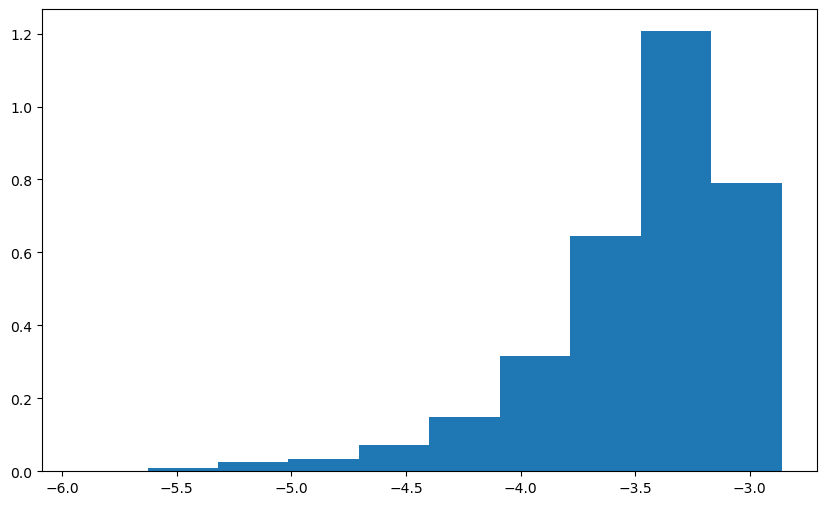

In [90]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))

deviation_orders = [np.log10(d) for d in deviations]
ax.hist(deviation_orders, density=True)
plt.show()

## Анализ
Проанализируем результаты проделанной работы.

### Решение СЛАУ
|           | Error (uniform), 1e-13 | Time (uniform), us | Error (normal), 1e-13 | Time (normal), us |
|-----------|------------------------|--------------------|-----------------------|-------------------|
| Simple    | 8.24                   | 367                | 9.52                  | 610               |
| Colpivot  | 0.36                   | 818                | 1.92                  | 665               |
| Fullpivot | 0.71                   | 1390               | 2.69                  | 701               |
| Numpy     | 0.28                   | 397                | 2.81                  | 438               |

**Для равномерной матрицы:**
1. Решение без выбора ведущего элемента имеет отклонение на порядок выше, чем все остальные.
2. Выбор ведущего элемента по столбцу увеличивает время решения незаметно, в то время, как выбор ведущего элемента по всей матрице - примерно в два раза.
3. Готовое решение numpy сравнимо по точности с решениями с выбором ведущего элемента, но при этом оно гораздо быстрее.

**Для нормальной матрицы:**
1. Решение простым методом Гаусса уже не на порядок менее точное, но близко: 9.52 - почти 10.
2. Отличия во времени выполнения меньше.

### Нахождение обратной матрицы
|           | Error (uniform), 1e-15 | Time (uniform), us | Error (normal), 1e-13 | Time (normal), us |
|-----------|------------------------|--------------------|-----------------------|-------------------|
| Fullpivot | 1.83                   | 1070               | 1.60                  | 884               |
| Numpy     | 1.10                   | 265                | 1.51                  | 272               | 

### Число обусловленности
|          | Condition number (uniform) | Condition number (normal) |
|----------|----------------------------|---------------------------|
| 1-norm   | 43.99                      | 60.44                     |
| inf-norm | 27.45                      | 64.83                     |

Результат почти полностью совпадает с numpy.

Порядок такого числа обусловленности можно интерпретировать, как максимум отношения ошибки решения к ошибке исходных данных, т.е. "сколько порядков точности мы теряем". Значит, может потеряться примерно 2 порядка: с точки зрения float64, мы можем уменьшить точность до $10^{-14}$ вместо $10^{-16}$.

### Нестабильное решение
|          | Error (uniform) | Error (normal) |
|----------|-----------------|----------------|
| Simple   | 71.54           | 1.34           |
| Colpivot | 8.15e-12        | 2.84e-13       |

Стоит отметить, что число обусловленности для такой равномерно сгенерированной матрицы - 3502.46, а нормальной - 72.98.
Это значит, что простой метод Гаусса может иметь большие отклонения даже при решении хорошо обусловленных матриц.

Чтобы это проиллюстрировать, были получены гистограммы отклонений, полученных при случайном шуме порядка 1e-6.

**Равномерная матрица**

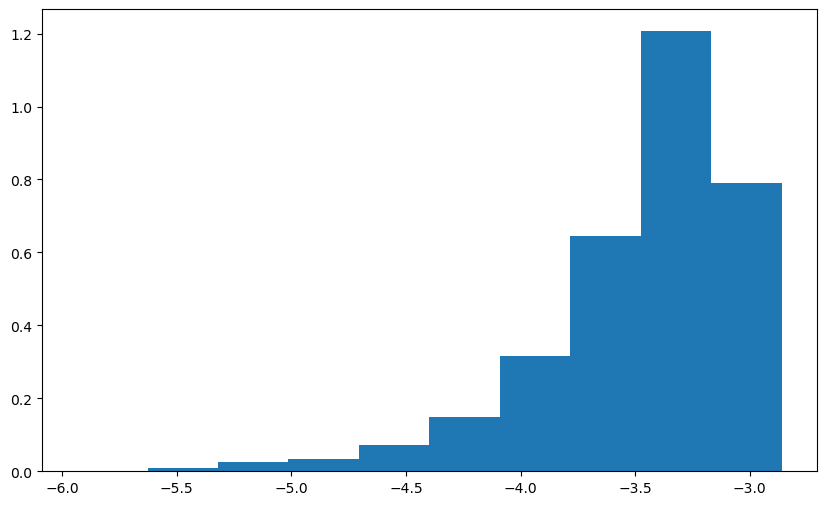

**Нормальная матрица**

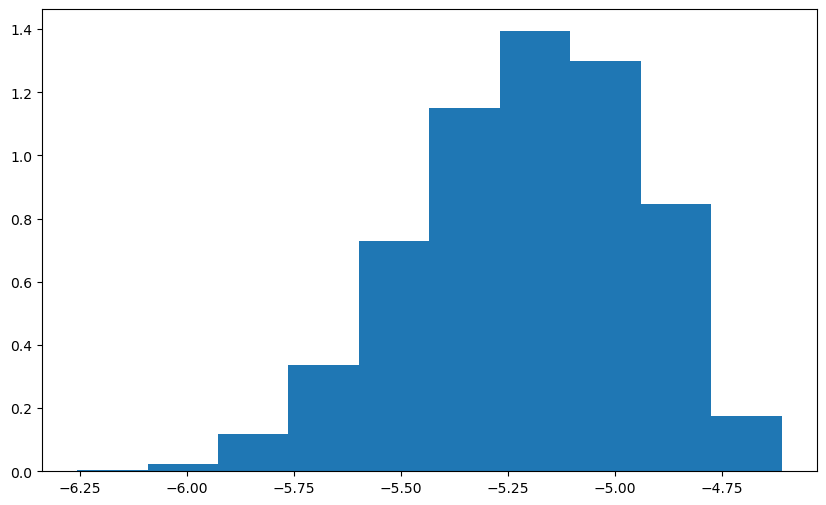

Как можно увидеть, по-настоящему плохо обусловленная матрица имеет моду распределения ошибок на 2 порядка больше.